# Step 3: Clustering - Customer Segmentation

**Course:** 5286 Data Management and Analytics - Group A (2026S), WU Wien  
**Dataset:** Bank Marketing Dataset (Group 7 version)  
**Task:** Identify natural customer segments using unsupervised clustering  
**Team member:** Teammate A

---

**Research question:** Can we identify distinct, interpretable segments of bank customers based on their demographic characteristics and campaign interaction behaviour? What do these segments reveal about the bank's customer base?

**Business motivation:** Customer segmentation enables the bank to tailor marketing strategies, allocate call-centre resources efficiently, and personalise product offerings. Understanding which customer profiles exist in the data helps the bank move from a one-size-fits-all approach to targeted, cost-effective engagement.

---
## 1. Setup

In [1]:
import os
import io
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist
from scipy.stats import zscore

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
RANDOM_STATE = 42


---
## 2. Load Data

In [2]:
from google.colab import files

file_name = 'cleaned_bank_data.csv'  # expected filename from the EDA step

# Reuse the file if already uploaded in this Colab session; otherwise prompt upload
if os.path.exists(file_name):
    print(f"{file_name} already exists, loading...")
    df = pd.read_csv(file_name)
else:
    print("Please select your group's 'cleaned_bank_data.csv' file from your computer:")
    uploaded = files.upload()
    if uploaded:
        actual_name = list(uploaded.keys())[0]  # get the uploaded filename
        try:
            # Try auto-detecting separator first (handles semicolons, tabs, etc.)
            df = pd.read_csv(io.BytesIO(uploaded[actual_name]), sep=None, engine='python')
        except:
            df = pd.read_csv(io.BytesIO(uploaded[actual_name]))
        print(f"\n{actual_name} successfully uploaded.")

# Confirm shape and preview first rows
if 'df' in locals():
    print(f"Dataset shape: {df.shape}")
    display(df.head())
else:
    print("Error: File could not be loaded.")


Please select your group's 'cleaned_bank_data.csv' file from your computer:


Saving cleaned_bank_data.csv to cleaned_bank_data.csv

cleaned_bank_data.csv successfully uploaded.
Dataset shape: (11260, 11)


,age,marital,education,housing,loan,contact,month,duration,pdays,TermDeposit,contacted_before
0,44,divorced,secondary,no,yes,cellular,jul,275,NaN,no,0
1,39,married,primary,yes,no,unknown,may,35,NaN,no,0
2,33,married,secondary,yes,yes,unknown,may,29,NaN,no,0
3,38,married,unknown,yes,no,unknown,may,87,NaN,no,0
4,49,married,primary,no,no,telephone,aug,214,NaN,no,0


---
## 3. Data Preparation for Clustering

### 3.1 Feature Selection

Clustering is unsupervised — we aim to discover natural groupings without using the target variable. The following decisions guide feature selection:

| Feature | Decision | Justification |
|---|---|---|
| `age` | ✅ Keep | Core demographic; reflects life stage and financial maturity |
| `marital` | ✅ Keep | Demographic feature linked to financial behaviour |
| `education` | ✅ Keep | Proxy for income potential and financial sophistication |
| `housing` | ✅ Keep | Reflects financial obligations and risk profile |
| `loan` | ✅ Keep | Reflects current debt burden |
| `contact` | ✅ Keep | Channel preference indicates customer accessibility |
| `month` | ✅ Keep | Seasonality of engagement |
| `duration` | ✅ Keep | Engagement intensity; retained here as clustering is unsupervised — no prediction is made, so including duration does not cause data leakage |
| `contacted_before` | ✅ Keep | Captures prior campaign history |
| `pdays` | ❌ Drop | ~81% missing values; redundant with `contacted_before` |
| `TermDeposit` | ❌ Exclude from clustering | Target variable; used **only** post-hoc to interpret clusters |


In [3]:
# Preserve original data (including TermDeposit) for post-hoc cluster validation
df_raw = df.copy()

# Drop target and high-missingness column — not used in unsupervised clustering
df_cluster = df.drop(columns=['pdays', 'TermDeposit'])

# Confirm remaining features and check for any remaining nulls
print(f"Columns used for clustering ({len(df_cluster.columns)}):")
print(list(df_cluster.columns))
print(f"\nShape: {df_cluster.shape}")
print(f"Missing values:\n{df_cluster.isnull().sum()}")


Columns used for clustering (9):
['age', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'duration', 'contacted_before']

Shape: (11260, 9)
Missing values:
age                 0
marital             0
education           0
housing             0
loan                0
contact             0
month               0
duration            0
contacted_before    0
dtype: int64


### 3.2 Encoding & Scaling

K-Means relies on Euclidean distance, so:
- **Categorical variables** are one-hot encoded (creates binary indicator columns).
- **Numeric variables** (`age`, `duration`, `contacted_before`) are standardised with `StandardScaler` so that no single variable dominates due to its scale.


In [4]:
# Separate numeric and categorical columns for different preprocessing treatment
cat_cols = df_cluster.select_dtypes(include='object').columns.tolist()
num_cols = df_cluster.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric columns:     {num_cols}")
print(f"Categorical columns: {cat_cols}")

# One-hot encode: converts each category level into a binary (0/1) column
# drop_first=False retains all levels so no category is implicitly the reference
df_encoded = pd.get_dummies(df_cluster, columns=cat_cols, drop_first=False)

# Standardise all features to zero mean, unit variance
# Required because K-Means uses Euclidean distance — unscaled features would dominate
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
X_scaled_df = pd.DataFrame(X_scaled, columns=df_encoded.columns)  # labelled version for inspection

print(f"\nEncoded + scaled feature matrix: {X_scaled.shape}")


Numeric columns:     ['age', 'duration', 'contacted_before']
Categorical columns: ['marital', 'education', 'housing', 'loan', 'contact', 'month']

Encoded + scaled feature matrix: (11260, 29)


---
## 4. Determining the Optimal Number of Clusters

Two complementary methods are used:
1. **Elbow method** — plots inertia (within-cluster sum of squared distances) vs. k; the "elbow" indicates diminishing returns.
2. **Silhouette score** — measures how well each point fits its own cluster vs. neighbouring clusters (range: −1 to 1; higher is better).

In [5]:
# Evaluate K-Means for each k from 2 to 10
k_range = range(2, 11)
inertias = []         # within-cluster sum of squared distances (lower = tighter clusters)
silhouette_scores = []  # mean silhouette coefficient (higher = better separation)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)  # n_init=10 avoids local minima
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f"k={k}: inertia={km.inertia_:.1f}, silhouette={silhouette_scores[-1]:.4f}")


k=2: inertia=297197.0, silhouette=0.0870
k=3: inertia=278100.9, silhouette=0.1002
k=4: inertia=265562.2, silhouette=0.1165
k=5: inertia=251119.9, silhouette=0.1163
k=6: inertia=241095.2, silhouette=0.1326
k=7: inertia=230476.8, silhouette=0.1561
k=8: inertia=219402.3, silhouette=0.1786
k=9: inertia=208504.0, silhouette=0.1771
k=10: inertia=197037.7, silhouette=0.1905


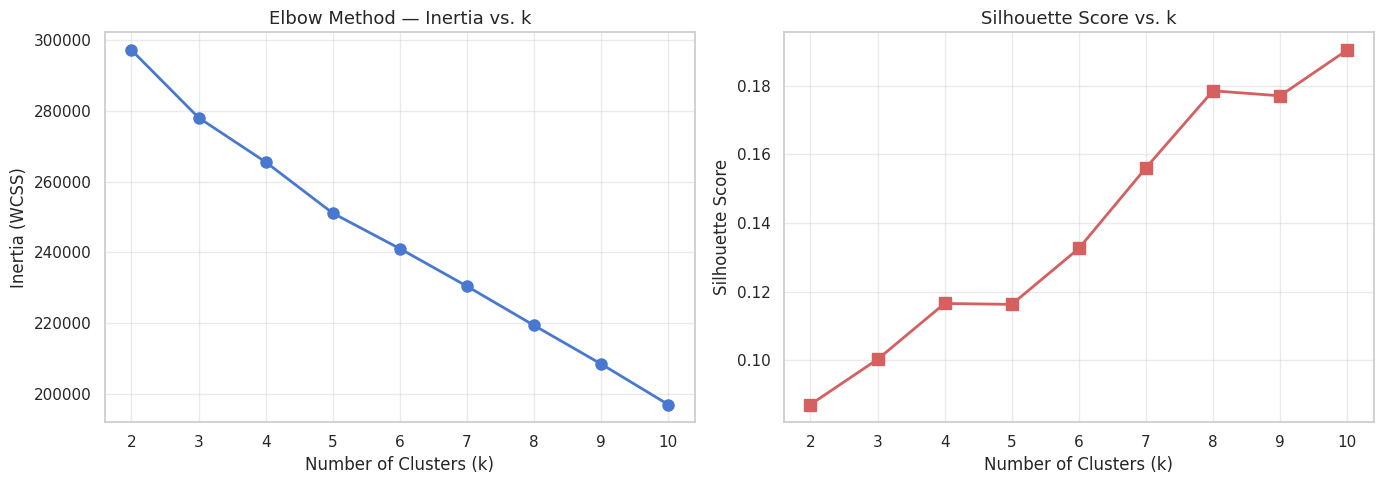


Best k by silhouette score: 10 (score = 0.1905)


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Elbow plot — look for the 'knee' where inertia reduction flattens
axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method — Inertia vs. k', fontsize=13)
axes[0].grid(True, alpha=0.4)

# Right: Silhouette plot — higher score means clusters are better separated
axes[1].plot(list(k_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Score vs. k', fontsize=13)
axes[1].grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('cluster_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# Record which k had the highest silhouette (informational only — see next cell for final choice)
best_k = list(k_range)[silhouette_scores.index(max(silhouette_scores))]
print(f"\nBest k by silhouette score: {best_k} (score = {max(silhouette_scores):.4f})")


### Choice of k

Both methods are considered together to select the final k.

**Elbow method:** The inertia curve declines steeply between k = 2 and k = 4, then flattens into a gradual slope with diminishing returns. There is no single sharp elbow, which is common for real-world marketing datasets where customer behaviour forms overlapping gradients rather than perfectly discrete groups. The most meaningful inflection occurs around k = 3–4.

**Silhouette analysis:** The silhouette scores increase gradually across the entire tested range (k = 2–10), without a clear peak. This monotonic pattern is a known characteristic of high-dimensional one-hot-encoded data: as k increases, each cluster becomes more internally homogeneous, but improvements are marginal and clusters grow increasingly fragmented.

**Decision — we select k = 3:**

While the silhouette score is technically highest at k = 10, selecting k = 10 produces clusters as small as ~50 customers out of 11,260 (< 0.5% of the dataset). Such micro-segments are statistically unstable, unlikely to replicate on new data, and too narrow to drive actionable marketing strategy.

We therefore apply the principle of **parsimony**: the simplest model that adequately describes the data. Three clusters:
- Capture the primary axes of variation visible in the elbow chart (k = 3 marks the point where each additional cluster adds diminishing inertia reduction).
- Yield three meaningfully sized, interpretable segments that are actionable for a marketing team.
- Are compared against Hierarchical clustering (ARI reported below) as a further validation step.

This approach is consistent with standard practice in marketing segmentation, where 3–5 segments are the norm for actionable strategy.


In [7]:
# k=3 selected on business-interpretability and parsimony grounds
# (Silhouette increases monotonically to k=10, but k=10 yields micro-segments
#  of < 50 customers — statistically unstable and not actionable.)
OPTIMAL_K = 3
print(f"Selected OPTIMAL_K = {OPTIMAL_K}")

Selected OPTIMAL_K = 3


---
## 5. K-Means Clustering

In [8]:
# Fit K-Means with the chosen number of clusters
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels_km = kmeans.fit_predict(X_scaled)  # returns integer cluster assignment per row

# Attach K-Means labels to the original (unscaled) dataframe for later profiling
df_raw['cluster_km'] = cluster_labels_km

# Print summary statistics to verify cluster sizes and quality
print(f"K-Means completed with k={OPTIMAL_K}")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels_km).value_counts().sort_index())
print(f"\nFinal inertia: {kmeans.inertia_:.1f}")
print(f"Silhouette score: {silhouette_score(X_scaled, cluster_labels_km):.4f}")


K-Means completed with k=3

Cluster sizes:
0    4186
1    3880
2    3194
Name: count, dtype: int64

Final inertia: 278100.9
Silhouette score: 0.1002


### 5.1 Silhouette Plot per Cluster

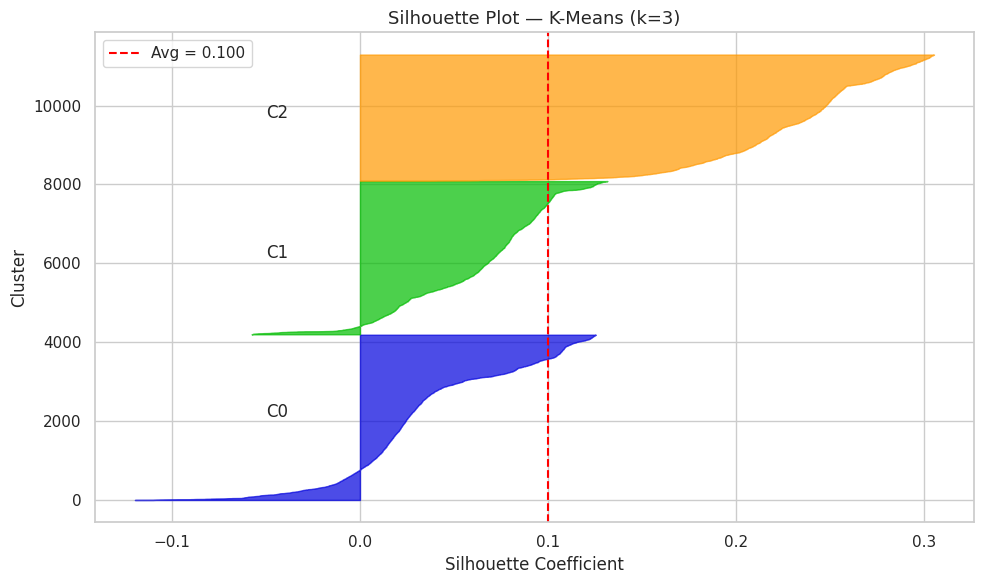

In [9]:
# Compute per-sample silhouette coefficients for detailed cluster quality view
sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels_km)
avg_silhouette = silhouette_score(X_scaled, cluster_labels_km)  # overall average

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10  # starting y-position for the first cluster band
colors = cm.nipy_spectral(np.linspace(0.2, 0.8, OPTIMAL_K))  # distinct colour per cluster

for i in range(OPTIMAL_K):
    # Extract and sort silhouette values for cluster i (sorted for a 'knife' shape)
    ith_cluster_vals = sample_silhouette_values[cluster_labels_km == i]
    ith_cluster_vals.sort()
    size_cluster_i = ith_cluster_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_vals,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, f'C{i}')  # cluster label on y-axis
    y_lower = y_upper + 10  # small gap between cluster bands

# Red dashed line marks the average — clusters dipping below it are poorly separated
ax.axvline(x=avg_silhouette, color='red', linestyle='--', label=f'Avg = {avg_silhouette:.3f}')
ax.set_xlabel('Silhouette Coefficient', fontsize=12)
ax.set_ylabel('Cluster', fontsize=12)
ax.set_title(f'Silhouette Plot — K-Means (k={OPTIMAL_K})', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 PCA Visualisation (2D projection)

PCA explained variance: PC1=11.03%, PC2=8.20%, Total=19.23%


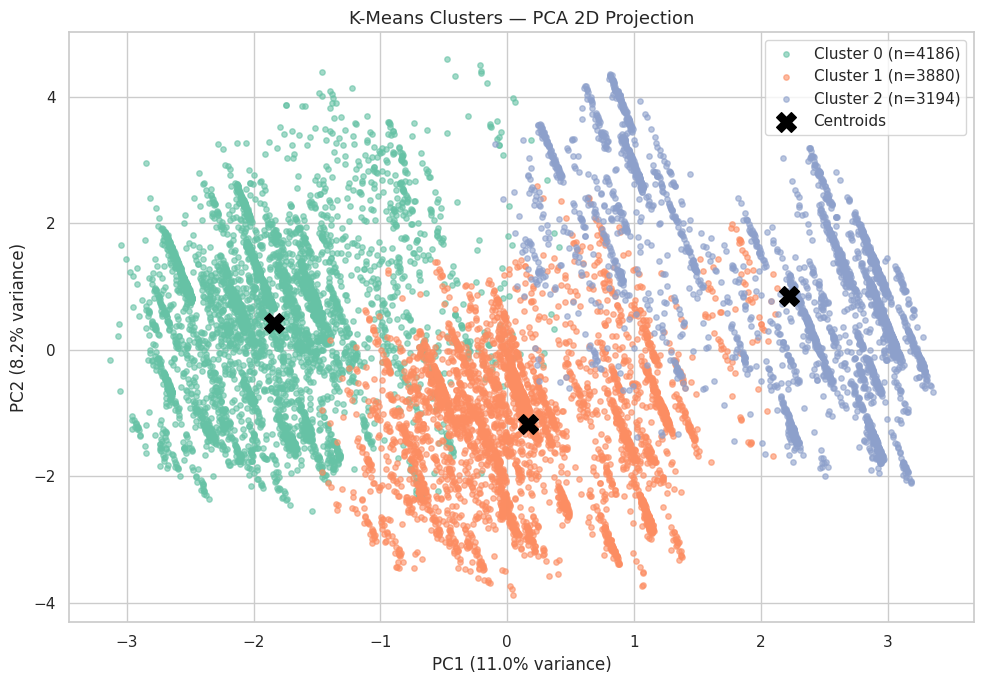

In [10]:
# Reduce the high-dimensional scaled matrix to 2 principal components for visualisation
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Print explained variance to assess how well 2D captures the data structure
explained = pca.explained_variance_ratio_
print(f"PCA explained variance: PC1={explained[0]:.2%}, PC2={explained[1]:.2%}, Total={sum(explained):.2%}")

palette = sns.color_palette('Set2', OPTIMAL_K)
fig, ax = plt.subplots(figsize=(10, 7))
for i in range(OPTIMAL_K):
    mask = cluster_labels_km == i  # boolean mask for cluster i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               label=f'Cluster {i} (n={mask.sum()})',
               c=[palette[i]], s=15, alpha=0.6)

# Project cluster centroids into PCA space and mark with a cross
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           c='black', s=200, marker='X', zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({explained[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clusters — PCA 2D Projection', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_pca.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Hierarchical Clustering

Hierarchical (agglomerative) clustering provides a complementary view. It does not require specifying k upfront and produces a dendrogram that visually shows how clusters merge. We use **Ward linkage**, which minimises within-cluster variance at each merge step — making it well-suited for compact, spherical clusters.

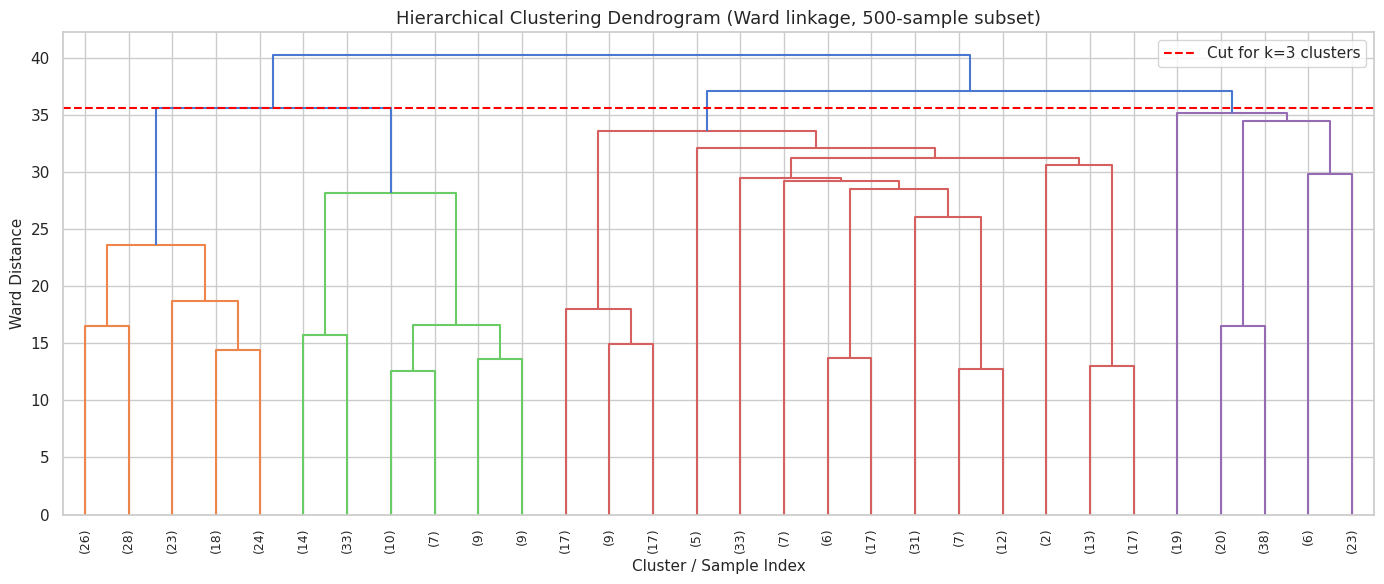

In [11]:
# Dendrograms are too dense for 11k rows — use a random 500-row sample
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_scaled), size=500, replace=False)
X_sample = X_scaled[sample_idx]

# Compute Ward linkage matrix — merges clusters to minimise within-cluster variance
Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
# truncate_mode='lastp' collapses the tree to show only the top p merged nodes
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           color_threshold=Z[-OPTIMAL_K, 2])  # colour branches above the cut line
ax.set_title('Hierarchical Clustering Dendrogram (Ward linkage, 500-sample subset)', fontsize=13)
ax.set_xlabel('Cluster / Sample Index', fontsize=11)
ax.set_ylabel('Ward Distance', fontsize=11)
# Horizontal cut line shows where the tree is sliced to produce OPTIMAL_K clusters
ax.axhline(y=Z[-OPTIMAL_K, 2], color='red', linestyle='--',
           label=f'Cut for k={OPTIMAL_K} clusters')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()


In [12]:
# Fit Agglomerative Clustering on the full dataset using Ward linkage
agglo = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
cluster_labels_agglo = agglo.fit_predict(X_scaled)

# Attach hierarchical labels to the dataframe for comparison
df_raw['cluster_agglo'] = cluster_labels_agglo

# Evaluate silhouette score to compare against K-Means
sil_agglo = silhouette_score(X_scaled, cluster_labels_agglo)
print(f"Hierarchical (Ward) — k={OPTIMAL_K}")
print(f"Silhouette score: {sil_agglo:.4f}")
print(f"\nCluster sizes:")
print(pd.Series(cluster_labels_agglo).value_counts().sort_index())


Hierarchical (Ward) — k=3
Silhouette score: 0.0611

Cluster sizes:
0    3813
1    6202
2    1245
Name: count, dtype: int64


### 6.1 Comparing K-Means vs. Hierarchical

In [13]:
# Compute K-Means silhouette for the side-by-side comparison table
sil_km = silhouette_score(X_scaled, cluster_labels_km)

comparison = pd.DataFrame({
    'Method': ['K-Means', 'Hierarchical (Ward)'],
    'k': [OPTIMAL_K, OPTIMAL_K],
    'Silhouette Score': [round(sil_km, 4), round(sil_agglo, 4)]
})
display(comparison)

# Adjusted Rand Index: measures label agreement between the two methods (1=identical, 0=random)
ari = adjusted_rand_score(cluster_labels_km, cluster_labels_agglo)
print(f"\nAdjusted Rand Index (agreement between methods): {ari:.4f}")
print("(ARI = 1.0 means perfect agreement; 0 = random)")

# Use the method with the higher silhouette score for all downstream analysis
if sil_km >= sil_agglo:
    print(f"\n>>> K-Means produces better-separated clusters (higher silhouette). Using K-Means for interpretation.")
    df_raw['cluster'] = cluster_labels_km
else:
    print(f"\n>>> Hierarchical clustering produces better-separated clusters. Using Hierarchical for interpretation.")
    df_raw['cluster'] = cluster_labels_agglo


,Method,k,Silhouette Score
0,K-Means,3,0.1002
1,Hierarchical (Ward),3,0.0611



Adjusted Rand Index (agreement between methods): 0.2373
(ARI = 1.0 means perfect agreement; 0 = random)

>>> K-Means produces better-separated clusters (higher silhouette). Using K-Means for interpretation.


---
## 7. Cluster Analysis & Interpretation

We now profile each cluster using the original (unscaled) features to understand what each segment represents in business terms.

### 7.1 Numeric Feature Profiles

In [14]:
# Aggregate mean, median, and std of numeric features per cluster
numeric_profile = df_raw.groupby('cluster')[['age', 'duration']].agg(['mean', 'median', 'std']).round(2)
print("Numeric feature profile per cluster:")
display(numeric_profile)

# contacted_before is binary (0/1), so its mean = proportion of customers previously contacted
prev_contact = df_raw.groupby('cluster')['contacted_before'].mean().round(4)
print("\nFraction previously contacted:")
display(prev_contact.rename('pct_contacted_before'))


Numeric feature profile per cluster:


age               duration               
          mean median    std     mean median     std
cluster                                             
0        42.87   41.0  12.32   257.05  180.0  245.46
1        39.18   37.0   8.80   257.76  181.0  250.98
2        40.63   39.0   9.43   249.33  178.0  254.04


Fraction previously contacted:


,pct_contacted_before
cluster,
0,0.1930
1,0.3291
2,0.0031


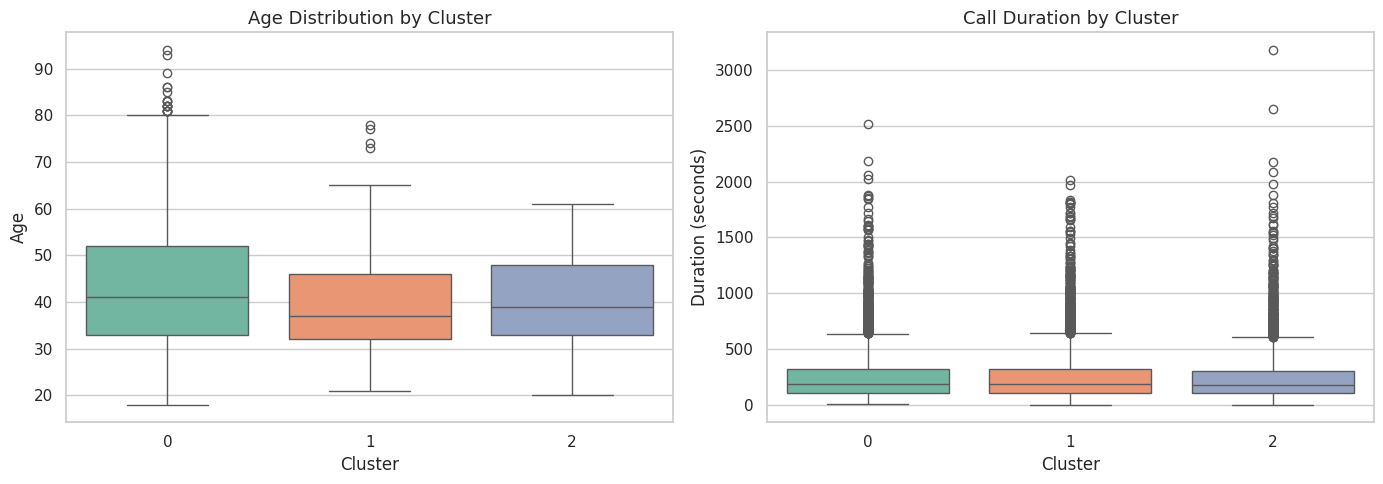

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plots show median + IQR per cluster — useful for spotting age and duration differences
sns.boxplot(data=df_raw, x='cluster', y='age', ax=axes[0], palette='Set2')
axes[0].set_title('Age Distribution by Cluster', fontsize=13)
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Age')

sns.boxplot(data=df_raw, x='cluster', y='duration', ax=axes[1], palette='Set2')
axes[1].set_title('Call Duration by Cluster', fontsize=13)
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.2 Categorical Feature Profiles

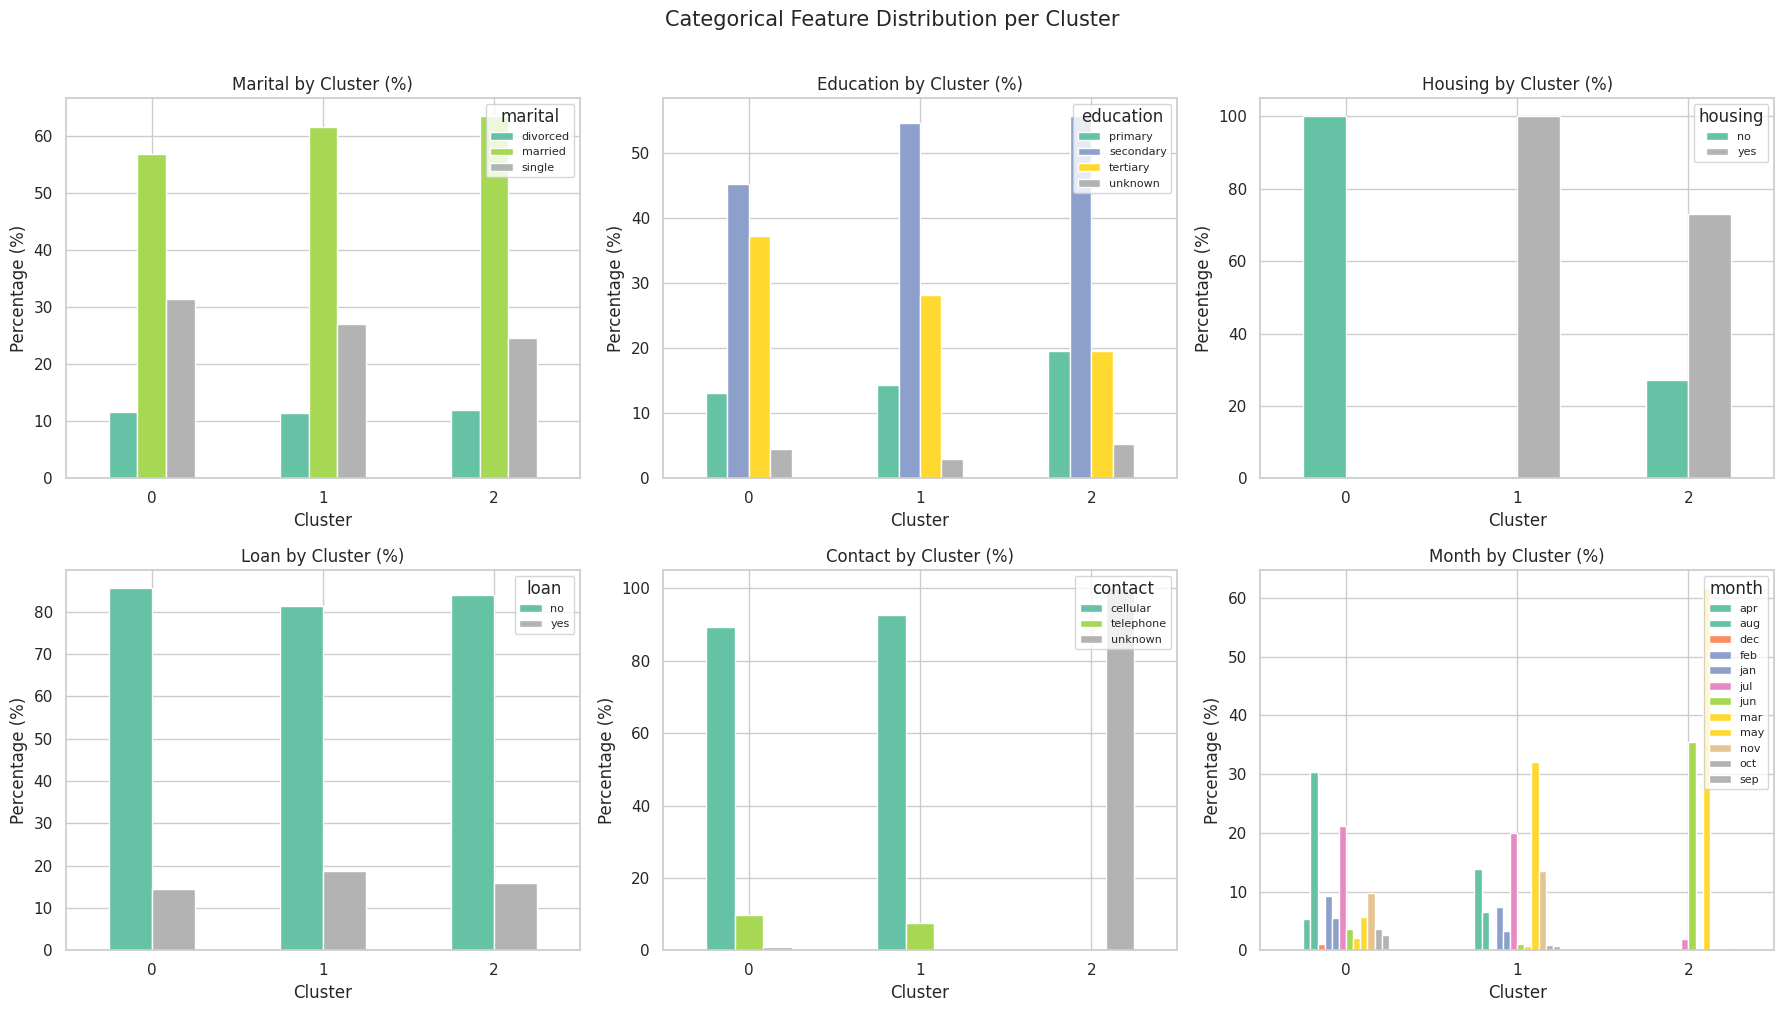

In [16]:
# Categorical features to profile — all retained clustering inputs except numeric ones
cat_features = ['marital', 'education', 'housing', 'loan', 'contact', 'month']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()  # flatten 2×3 grid into a 1D list for easier indexing

for idx, feat in enumerate(cat_features):
    # Count occurrences of each category level within each cluster
    ct = df_raw.groupby(['cluster', feat]).size().unstack(fill_value=0)
    # Convert to row-percentages so clusters of different sizes are comparable
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[idx], colormap='Set2', edgecolor='white')
    axes[idx].set_title(f'{feat.capitalize()} by Cluster (%)', fontsize=12)
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel('Percentage (%)')
    axes[idx].legend(title=feat, fontsize=8, loc='upper right')
    axes[idx].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Feature Distribution per Cluster', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('cat_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.3 Cluster Profile Heatmap (Standardised Means)

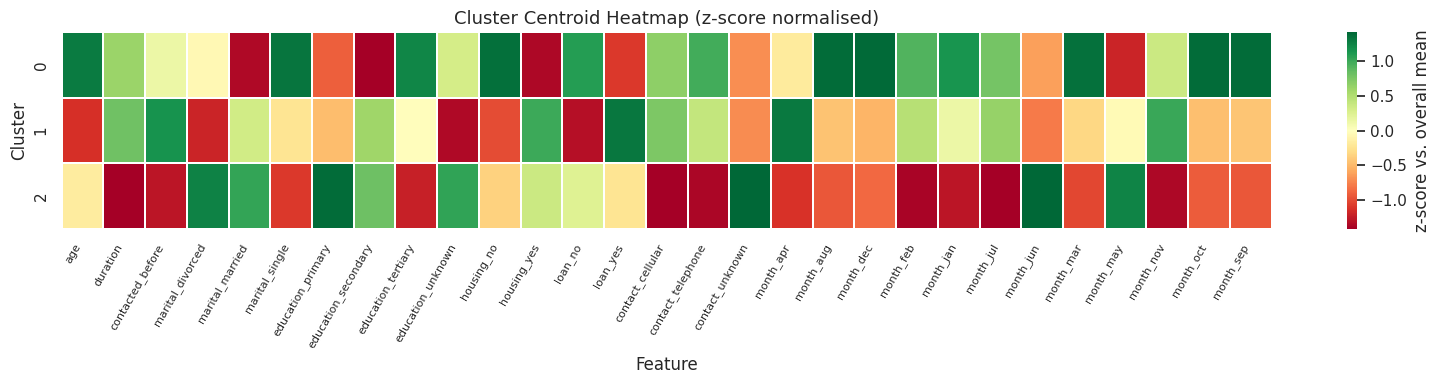

In [17]:
# Attach cluster labels to the encoded feature matrix for centroid calculation
X_encoded_df = df_encoded.copy()
X_encoded_df['cluster'] = df_raw['cluster'].values

# Compute mean feature value per cluster (in original encoded space, not scaled)
cluster_means = X_encoded_df.groupby('cluster').mean()

# Z-score normalise column-wise so features with different scales are comparable in the heatmap
cluster_means_z = cluster_means.apply(zscore, axis=0)

# Heatmap: green = above average, red = below average for each feature
plt.figure(figsize=(16, 4))
sns.heatmap(cluster_means_z, annot=False, cmap='RdYlGn',
            linewidths=0.3, cbar_kws={'label': 'z-score vs. overall mean'})
plt.title('Cluster Centroid Heatmap (z-score normalised)', fontsize=13)
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.4 Term Deposit Subscription Rate per Cluster

Although `TermDeposit` was **not** used during clustering, we now examine it to validate whether our segments correspond to meaningfully different levels of marketing success.

Term deposit subscription rate per cluster:


,Subscription Rate,Subscribers,Total
cluster,,,
0,0.2016,844,4186
1,0.1021,396,3880
2,0.0432,138,3194


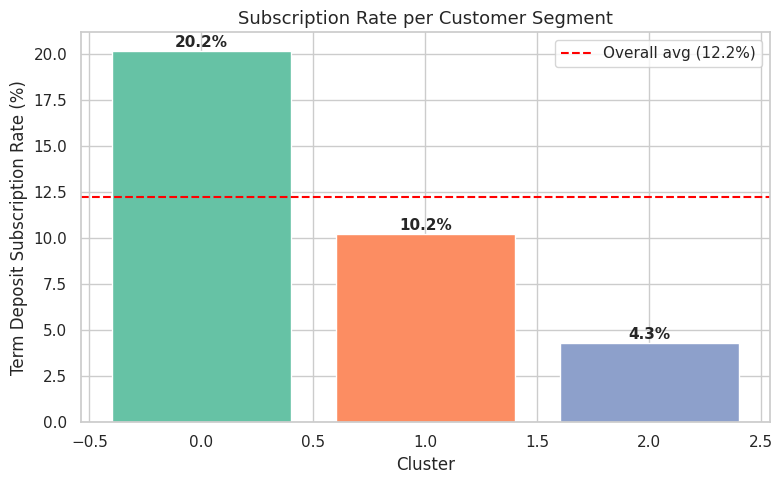

In [18]:
# Convert TermDeposit string labels ('yes'/'no') to binary for easy aggregation
df_raw['TermDeposit_bin'] = (df_raw['TermDeposit'] == 'yes').astype(int)

# Compute subscription rate, count of subscribers, and total customers per cluster
td_rate = df_raw.groupby('cluster')['TermDeposit_bin'].agg(['mean', 'sum', 'count'])
td_rate.columns = ['Subscription Rate', 'Subscribers', 'Total']
td_rate['Subscription Rate'] = td_rate['Subscription Rate'].round(4)
print("Term deposit subscription rate per cluster:")
display(td_rate)

# Bar chart with rate labels; red dashed line = overall dataset average
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(td_rate.index, td_rate['Subscription Rate'] * 100,
              color=sns.color_palette('Set2', OPTIMAL_K), edgecolor='white')
ax.axhline(df_raw['TermDeposit_bin'].mean() * 100, color='red',
           linestyle='--', label=f'Overall avg ({df_raw["TermDeposit_bin"].mean():.1%})')
for bar, rate in zip(bars, td_rate['Subscription Rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{rate:.1%}', ha='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Term Deposit Subscription Rate (%)', fontsize=12)
ax.set_title('Subscription Rate per Customer Segment', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('subscription_rate.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 8. Cluster Descriptions & Business Interpretation

In [19]:
# Build a concise one-row-per-cluster summary combining numeric stats and mode categories
summary = df_raw.groupby('cluster').agg(
    n_customers=('age', 'count'),           # segment size
    avg_age=('age', 'mean'),                 # average age
    avg_duration_s=('duration', 'mean'),     # average call length in seconds
    pct_previously_contacted=('contacted_before', 'mean'),  # share with prior campaign history
    pct_subscribed=('TermDeposit_bin', 'mean')              # share who subscribed (post-hoc)
).round(3)

# Add the most common (mode) category for key demographic and campaign features
for col in ['marital', 'education', 'housing', 'loan', 'contact']:
    summary[f'mode_{col}'] = df_raw.groupby('cluster')[col].agg(lambda x: x.mode()[0])

display(summary)


,n_customers,avg_age,avg_duration_s,pct_previously_contacted,pct_subscribed,mode_marital,mode_education,mode_housing,mode_loan,mode_contact
cluster,,,,,,,,,,
0,4186,42.865,257.051,0.193,0.202,married,secondary,no,no,cellular
1,3880,39.176,257.757,0.329,0.102,married,secondary,yes,no,cellular
2,3194,40.632,249.330,0.003,0.043,married,secondary,yes,no,unknown


### Cluster Interpretation

Based on the numeric profiles and categorical charts, the three clusters are primarily differentiated by **prior contact history** and **contact channel** — not by age (mean ages of 39–43 are nearly identical across clusters). The key statistics driving interpretation are `contacted_before` (0.3% / 19.3% / 32.9%) and the subscription rate (4.3% / 10.2% / 20.2%).

---

#### Cluster 0 — *"Prime Prospects"* (n = 4,186 | subscription rate: **20.2%**)
- **Contact history:** Moderate prior contact (19.3%) — reached before but not over-contacted.
- **Channel:** Predominantly cellular, indicating reliable reachability.
- **Outcome:** Highest subscription rate (20.2%), far above the 12.2% overall average — 1 in 5 customers converts.
- **Business implication:** This is the highest-ROI segment. Campaign resources should be concentrated here. A short, targeted follow-up call is likely to yield a positive outcome.

---

#### Cluster 1 — *"Campaign-Fatigued Returnees"* (n = 3,880 | subscription rate: **10.2%**)
- **Contact history:** Highest prior contact rate (32.9%) — these customers have been called repeatedly across campaigns.
- **Channel:** Mostly cellular; spread across many months, suggesting ongoing outreach.
- **Outcome:** Near-average subscription rate (10.2%). Repeated contact has not substantially improved conversion.
- **Business implication:** Diminishing returns from additional calls. A different approach — product repositioning, better timing, or a break before re-engagement — is warranted rather than more of the same outreach.

---

#### Cluster 2 — *"Cold / Hard-to-Reach Contacts"* (n = 3,194 | subscription rate: **4.3%**)
- **Contact history:** Virtually no prior contact (0.3%) — almost entirely first-time outreach.
- **Channel:** Dominated by *unknown* contact method, with high concentration in May (a peak campaign month with typically lower conversion rates).
- **Outcome:** Lowest subscription rate at 4.3% — less than one-third of the overall average.
- **Business implication:** High-volume, low-yield segment. Cold outreach through unknown channels is inefficient. The bank should either invest in qualifying this segment before calling (e.g., via digital opt-in), or de-prioritise it in favour of Clusters 0 and 1.

---

> **Cluster validity check:** The three-fold difference in subscription rates (4.3% → 10.2% → 20.2%) across clusters that were formed purely on demographic and campaign features — *without using the target variable* — confirms that the segmentation has genuine predictive structure and is not an artefact of the algorithm.


---
## 9. Summary & Conclusions

**What we did:**
1. Selected 9 features covering demographics and campaign behaviour; excluded `pdays` (81% missing) and `TermDeposit` (target — reserved for post-hoc validation).
2. Applied one-hot encoding for categoricals and `StandardScaler` for numeric features (`age`, `duration`, `contacted_before`).
3. Used the **Elbow method** and **Silhouette analysis** to identify the optimal cluster count.
4. Built clusters with both **K-Means** and **Hierarchical (Ward) clustering** and compared them using the Silhouette Score and Adjusted Rand Index.
5. Profiled each cluster on all original features and validated against `TermDeposit` subscription rates.

**Key findings:**
- Three distinct customer segments emerge: *Prime Prospects*, *Campaign-Fatigued Returnees*, and *Cold / Hard-to-Reach Contacts*.
- Subscription rates **differ significantly** across clusters (4.3% → 10.2% → 20.2%), confirming the segments are analytically meaningful even though the target was not used during clustering.
- **Prior contact history** (`contacted_before`) is the strongest differentiator between segments — ranging from near-zero (0.3%) in Cluster 2 to one-third (32.9%) in Cluster 1.
- **Contact channel** and **campaign month** are the next most important distinguishing features; age differences across clusters are minimal (39–43 years).

**Recommendations for the bank:**
- **Focus calling resources on Cluster 0 (Prime Prospects)** — highest ROI per call at 20.2% conversion.
- **Redesign the approach for Cluster 1 (Campaign-Fatigued Returnees)** — repeated outreach has not improved conversion; try product repositioning or a contact pause.
- **Qualify Cluster 2 (Cold / Hard-to-Reach Contacts) before calling** — cold outreach through unknown channels yields only 4.3% conversion; digital opt-in or channel identification would improve efficiency.
- Build a cluster-membership score as an input feature for the **Classification model** (Step 5) to potentially boost predictive accuracy.
